# 4 — 基于 Isolation Forest 的异常轨迹过滤（参照 Wang et al., 2026）

**基础数据**：`wifi_track_data/dacang/track_data/dacang_track_data_0511.csv`

**CSV 列**：`m, x, y, hour, oriMac, calender, seq` — 时间用 `hour`（小数小时）+ `calender` 拼伪时间轴；路径用相邻 `(x,y)`（按 `seq` 排序）。

**IF 样本单元（基本计算单位）**：**每个日历日 `calender` × 每个 `oriMac`** 一条样本。同一 MAC 跨多日会拆成多条，互不合并；`m` 通常与该二元组一一对应，仅作与原始表对齐的键。

**日×MAC 五维指标**（与论文 Fig. 4 英文轴名一致；按上述单元分组聚合）：

1. **Occurrence frequency (count)** — `occurrence_frequency_count`：该单元内行数。
2. **Avg. active timestamp (h)** — `avg_active_timestamp_h`：各点 `hour` 表示 **0–24 的钟点（小数小时）**；对该单元取**平均钟点**。若单元内 `hour` 跨度 **>12h**（疑似跨午夜），改用**圆上平均**再映射到 **`[0,24)`**。
3. **Movement distances (m, log10)** — `movement_distances_m_log10`：按 `seq` 相邻点欧氏距离累计，再 `log10(max(·, 1e-12))`（坐标单位）。
4. **Med. active timestamp (h)** — `med_active_timestamp_h`：按 `seq` 取**首尾**两点的 `t_abs = calender*86400 + hour*3600`，取时间中点，再减去**该日** `calender×86400` 得到**当日钟点**，并归一化到 **`[0,24)`**。
5. **Durations (h)** — `durations_h`：同单元内 `t_abs` 最大与最小之差（小时）。

**参照**：Wang et al. (2026) Fig. 4 pairplot；Isolation Forest `contamination=0.1`。

**预过滤**：`movement_distances_m_log10` 小于 0（等价于累计路径长小于 1，当前 XY 单位）的整个**日×MAC 单元**从 `feat_df` 与原始 `df` 中剔除，**不参与** Isolation Forest、Fig. 4 pairplot、箱线图，也不会进入 IF 之后的导出结果。


In [68]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

if "IPython" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")


In [69]:
def find_repo_root() -> Path:
    c = Path.cwd().resolve()
    for p in [c, c.parent, c.parent.parent]:
        if (p / "utils_tool" / "utils.py").is_file() and (p / "wifi_track_data").is_dir():
            return p
    raise FileNotFoundError(
        "未找到项目根目录（需包含 utils_tool 与 wifi_track_data）。请在项目根或 data_clean 下运行。"
    )


REPO = find_repo_root()

TRACK_CSV = REPO / "wifi_track_data" / "dacang" / "track_data" / "dacang_track_data_0511.csv"

OUT_DIR = TRACK_CSV.parent
STEM = TRACK_CSV.stem
OUT_FILTERED = OUT_DIR / f"{STEM}_if_filtered.csv"
OUT_LABELS = OUT_DIR / f"{STEM}_if_traj_labels.csv"
OUT_META = OUT_DIR / f"{STEM}_if_filter_meta.json"
OUT_FIG = OUT_DIR / f"{STEM}_fig4_isolation_forest_pairplot.png"

CONTAMINATION = 0.1
RANDOM_STATE = 42

print("REPO:", REPO)
print("TRACK:", TRACK_CSV)


REPO: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation
TRACK: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\track_data\dacang_track_data_0511.csv


In [70]:
df = pd.read_csv(TRACK_CSV)
df.columns = [c.strip() for c in df.columns]
_req = {"m", "x", "y", "hour", "seq", "calender", "oriMac"}
miss = _req - set(df.columns)
if miss:
    raise ValueError(f"CSV 缺少列: {sorted(miss)}；当前 {list(df.columns)}")

print(df.shape)
print(df.head(2))
print("日×MAC 单元数 (calender×oriMac):", df.groupby(["calender", "oriMac"], sort=False).ngroups)
print("轨迹键 m 数（与原始列对齐）:", df["m"].nunique())

(294283, 7)
                         m        x        y       hour               oriMac  \
0  7.5-48,74,38,155,214,98  205.899  103.487  17.026812  48,74,38,155,214,98   
1  7.5-48,74,38,155,214,98  202.551  111.363  17.203623  48,74,38,155,214,98   

   calender  seq  
0       7.5    0  
1       7.5    1  
日×MAC 单元数 (calender×oriMac): 1397
轨迹键 m 数（与原始列对齐）: 1397


In [71]:
# --- Trajectory features: dacang_track_data_0511.csv (hour, calender, seq, x, y) ---
FEATURE_COLS = [
    "occurrence_frequency_count",
    "avg_active_timestamp_h",
    "movement_distances_m_log10",
    "med_active_timestamp_h",
    "durations_h",
]

# Exact strings for pairplot axes (paper Fig. 4 labels).
FIG4_LABELS = {
    "occurrence_frequency_count": "Occurrence frequency (count)",
    "avg_active_timestamp_h": "Avg. active timestamp (h)",
    "movement_distances_m_log10": "Movement distances (m, log10)",
    "med_active_timestamp_h": "Med. active timestamp (h)",
    "durations_h": "Durations (h)",
}


def _t_abs_sec(cal, hr):
    return cal.astype(float) * 86400.0 + hr.astype(float) * 3600.0


def trajectory_path_length_xy(sub: pd.DataFrame) -> float:
    sub = sub.sort_values("seq")
    x = sub["x"].to_numpy(dtype=float)
    y = sub["y"].to_numpy(dtype=float)
    if len(x) < 2:
        return 0.0
    return float(np.hypot(np.diff(x), np.diff(y)).sum())


def _wrap_h24(h: float) -> float:
    """Map a clock hour to [0, 24)."""
    return ((float(h) % 24.0) + 24.0) % 24.0


def _mean_hour_clock(hr: np.ndarray) -> float:
    """Mean clock in [0,24); use circular mean if span suggests midnight wrap."""
    hr = np.asarray(hr, dtype=float)
    if hr.size == 0:
        return 0.0
    if float(hr.max() - hr.min()) <= 12.0:
        return _wrap_h24(float(np.mean(hr)))
    ang = hr * (2.0 * np.pi / 24.0)
    m = float(np.arctan2(np.mean(np.sin(ang)), np.mean(np.cos(ang))))
    if m < 0:
        m += 2.0 * np.pi
    return m / (2.0 * np.pi) * 24.0


def build_traj_features(df: pd.DataFrame) -> pd.DataFrame:
    """One IF row per (calender, oriMac); `m` from first row for alignment with raw CSV."""
    df = df.copy()
    df["_t_abs"] = _t_abs_sec(df["calender"], df["hour"])
    rows = []
    for (cal, ori_mac), sub in df.groupby(["calender", "oriMac"], sort=False):
        sub = sub.sort_values("seq")
        n = len(sub)
        ta = sub["_t_abs"].to_numpy(dtype=float)
        durations_h = float((ta.max() - ta.min()) / 3600.0)
        dist_xy = trajectory_path_length_xy(sub)
        hr = sub["hour"].astype(float).to_numpy()
        avg_active_timestamp_h = _mean_hour_clock(hr)
        t0, t1 = float(ta[0]), float(ta[-1])
        mid_abs = 0.5 * (t0 + t1)
        cal_sec = float(cal) * 86400.0
        med_active_timestamp_h = _wrap_h24((mid_abs - cal_sec) / 3600.0)
        m_val = sub["m"].iloc[0]
        rows.append(
            {
                "calender": cal,
                "oriMac": ori_mac,
                "m": m_val,
                "occurrence_frequency_count": n,
                "avg_active_timestamp_h": avg_active_timestamp_h,
                "med_active_timestamp_h": med_active_timestamp_h,
                "durations_h": durations_h,
                "movement_distance": dist_xy,
                "movement_distances_m_log10": float(np.log10(max(dist_xy, 1e-12))),
            }
        )
    return pd.DataFrame(rows)


feat_df = build_traj_features(df)

# 剔除 movement_distances_m_log10 < 0 的日×MAC 单元（等价于原始累计路径长 < 1，XY 单位），不参与 IF / pairplot / 箱线图，也不写入导出 df。
ROWS_BEFORE_LOWMOVE_DROP = len(df)
TRAJ_BEFORE_LOWMOVE_DROP = int(df.groupby(["calender", "oriMac"], sort=False).ngroups)
msk = feat_df["movement_distances_m_log10"] >= 0
feat_df = feat_df.loc[msk].reset_index(drop=True)
N_DROPPED_LOW_MOV_LOG = TRAJ_BEFORE_LOWMOVE_DROP - len(feat_df)
units_keep = feat_df[["calender", "oriMac"]].drop_duplicates()
df = df.merge(units_keep, on=["calender", "oriMac"], how="inner").reset_index(drop=True)
print(
    f"剔除 movement_distances_m_log10<0: 日×MAC 单元 {N_DROPPED_LOW_MOV_LOG} 个 "
    f"(剩余 {len(feat_df)}/{TRAJ_BEFORE_LOWMOVE_DROP})；删去 df 行 {ROWS_BEFORE_LOWMOVE_DROP - len(df)} 行"
)
feat_df.head()


剔除 movement_distances_m_log10<0: 日×MAC 单元 4 个 (剩余 1393/1397)；删去 df 行 191 行


,calender,oriMac,m,occurrence_frequency_count,avg_active_timestamp_h,med_active_timestamp_h,durations_h,movement_distance,movement_distances_m_log10
0,7.5,"48,74,38,155,214,98","7.5-48,74,38,155,214,98",61,21.645355,20.446739,6.839855,509.907826,2.707492
1,7.5,"48,74,38,133,29,213","7.5-48,74,38,133,29,213",28,19.633333,20.228882,6.404141,288.006568,2.459402
2,7.5,"20,178,229,137,47,142","7.5-20,178,229,137,47,142",192,23.223698,20.583333,6.833333,1241.444948,3.093927
3,7.6,"204,129,42,183,42,73","7.6-204,129,42,183,42,73",602,5.758402,10.480000,20.293333,5333.220576,3.726990
4,7.6,"48,74,38,133,29,213","7.6-48,74,38,133,29,213",139,2.557165,12.075000,24.150000,818.557937,2.913049


In [72]:
if len(feat_df) == 0:
    raise ValueError(
        "feat_df 为空：全部被 movement_distances_m_log10<0 剔除，请检查数据或距离尺度。"
    )

X = feat_df[FEATURE_COLS].to_numpy(dtype=np.float64)
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

clf = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
pred = clf.fit_predict(Xz)
# sklearn: 1 = 正常, -1 = 异常
feat_df["if_label"] = pred
feat_df["if_score"] = clf.decision_function(Xz)

n_out = int((pred == -1).sum())
n_in = int((pred == 1).sum())
print(
    f"正常日×MAC单元: {n_in}, 异常: {n_out}, contamination≈{n_out / len(pred):.3f}"
)

正常日×MAC单元: 1253, 异常: 140, contamination≈0.101


In [73]:
# 若未重跑特征单元，feat_df 可能无 calender/oriMac；从 df 按 m 补全（与当前数据 m↔日×MAC 一一对应）。
if not {"calender", "oriMac"}.issubset(feat_df.columns):
    _m2day = df[["m", "calender", "oriMac"]].drop_duplicates(subset=["m"], keep="first")
    feat_df = feat_df.merge(_m2day, on="m", how="left")

keep_units = feat_df.loc[feat_df["if_label"] == 1, ["calender", "oriMac"]].drop_duplicates()
df_f = df.merge(keep_units, on=["calender", "oriMac"], how="inner").copy()

df_f.to_csv(OUT_FILTERED, index=False)
feat_df.to_csv(OUT_LABELS, index=False)

meta = {
    "reference": "Wang et al., 2026, Architectural Intelligence (Fig. 4; 2.1.1 step 3)",
    "method": "IsolationForest",
    "contamination": CONTAMINATION,
    "if_sample_unit": "calender × oriMac (one feature row per day per MAC)",
    "feature_columns": FEATURE_COLS,
    "time_model": "t_abs = calender*86400 + hour*3600; avg/med active timestamps are clock-of-day in [0,24) h (circular mean for avg when hour span>12); order by seq; path from x,y",
    "input_csv": str(TRACK_CSV.relative_to(REPO)),
    "output_filtered_csv": str(OUT_FILTERED.relative_to(REPO)),
    "output_labels_csv": str(OUT_LABELS.relative_to(REPO)),
    "rows_before_low_move_log_drop": int(ROWS_BEFORE_LOWMOVE_DROP),
    "traj_before_low_move_log_drop": int(TRAJ_BEFORE_LOWMOVE_DROP),
    "n_dropped_traj_low_move_log": int(N_DROPPED_LOW_MOV_LOG),
    "n_rows_in": int(len(df)),
    "n_rows_out": int(len(df_f)),
    "n_traj_in": int(df.groupby(["calender", "oriMac"], sort=False).ngroups),
    "n_traj_out": int(len(keep_units)),
}
OUT_META.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print("已写入:", OUT_FILTERED)
print("已写入:", OUT_LABELS)
print("已写入:", OUT_META)

已写入: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\track_data\dacang_track_data_0511_if_filtered.csv
已写入: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\track_data\dacang_track_data_0511_if_traj_labels.csv
已写入: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\track_data\dacang_track_data_0511_if_filter_meta.json


## Fig. 4 可视化

5×5 **pairplot**（对角 KDE）；红 normal / 蓝 abnormal。仅含预过滤后 `movement_distances_m_log10` ≥ 0 的日×MAC 单元（见首格说明）。

**轴名（与论文一致，时间戳两轴为小时 h）**：Occurrence frequency (count) · Avg. active timestamp (h) · Movement distances (m, log10) · Med. active timestamp (h) · Durations (h)。


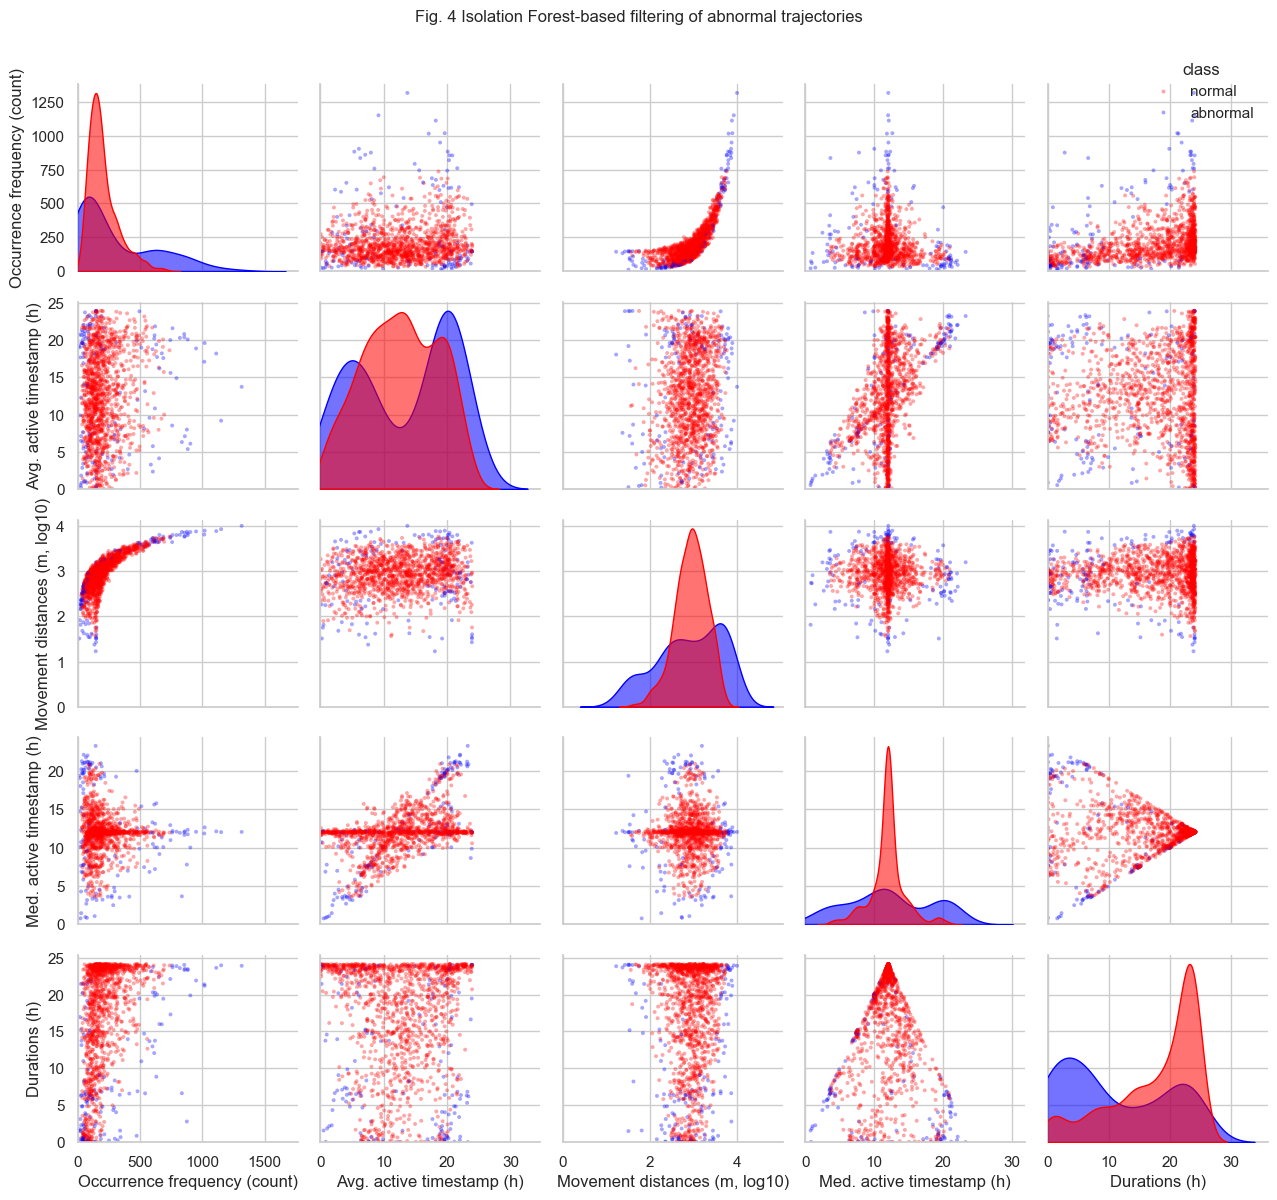

已保存: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\track_data\dacang_track_data_0511_fig4_isolation_forest_pairplot.png


In [75]:
plot_df = feat_df[FEATURE_COLS + ["if_label"]].copy()
plot_df["class"] = plot_df["if_label"].map({1: "normal", -1: "abnormal"})
plot_df = plot_df.rename(columns=FIG4_LABELS)
label_col = "class"
col_names = list(FIG4_LABELS.values())

g = sns.pairplot(
    plot_df,
    vars=col_names,
    hue=label_col,
    hue_order=["normal", "abnormal"],
    palette={"normal": "red", "abnormal": "blue"},
    diag_kind="kde",
    corner=False,
    plot_kws={"s": 8, "alpha": 0.35, "linewidths": 0, "rasterized": True},
    diag_kws={"common_norm": False, "fill": True, "alpha": 0.55},
    height=2.35,
    aspect=1.0,
)
for _ax in g.axes.flat:
    _ax.set_xlim(left=0)
    _ax.set_ylim(bottom=0)
leg = getattr(g, "_legend", None)
if leg is not None:
    leg.set_bbox_to_anchor((0.98, 0.98))
    leg.set_loc("upper right")
g.fig.suptitle(
    "Fig. 4 Isolation Forest-based filtering of abnormal trajectories",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
g.fig.savefig(OUT_FIG, dpi=200, bbox_inches="tight")
try:
    __IPYTHON__  # noqa: F821
    plt.show()
except NameError:
    plt.close("all")
print("已保存:", OUT_FIG)
